# Figure: Application to Neural Data

This notebook reproduces "Figure 5: **Results: (mu)-ECoG Data**" from the manuscript. Note that this figure relies on intermediate outputs (vector representations of independent sources), which are saved in `notebooks/output`. The notebook `create_representations.ipynb` can be used to reproduce the creation of the representations.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.stats import multivariate_normal
sys.path.append("..")

from experiments.config import experiments
from src.utils import to_list_of_dicts
from src.data import load_dataset

In [2]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams["axes.labelsize"] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.titlesize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

The `get_extremile_weights` function is used to compute the "average of max" criterion given a sequence of numbers. Precisely, setting `r` gives a sequence of `n` weights that can be used to take a weighted average of `n` elements that recovers the average of the maximum of over combination of `r` elements in the original sequence.

In [3]:
def get_extremile_weights(n, r):
    return (
        (np.arange(n, dtype=np.float64) + 1) ** r
        - np.arange(n, dtype=np.float64) ** r
    ) / (n**r)

def compute_columnwise_extremile(performance, r):
    n, t = performance.shape
    spectrum = get_extremile_weights(n, r)
    return np.sort(performance.T, axis=1) @ spectrum

In [4]:
experiment =  "reach_multitarget_icassp"

save_dir = f"../experiments/out/{experiment}"
lst_ = to_list_of_dicts(experiments[experiment])

def load_result(i, save_dir=save_dir):
    fp = os.path.join(save_dir, f'{i:03d}.json')
    if os.path.exists(fp):
        with open(fp, "r") as f:
            return json.load(f)['metrics']
    else:
        return None
    
metrics = []
lst = []
opt_errors = 0
time_errors = 0
for i in range(len(lst_)):
    try:
        result = load_result(i)
        if result is None:
            opt_errors += 1
        else:
            metrics.append(load_result(i))
            lst.append(lst_[i])
    except FileNotFoundError:
        print(f"\t TIMED OUT: {i}")
        print(lst_[i])
        time_errors += 1

print(f"Optimization errors {opt_errors}")
print(f"Time errors {time_errors}")
# df = pd.DataFrame(lst).reset_index()
df = pd.DataFrame(lst_).reset_index()
df

Optimization errors 0
Time errors 0


,index,dataset,lr_unmix,lr_model,max_iter,eval_iter,seed,batch_size_trials,batch_size_samples,density,optim,n_layers,lam
0,0,reach-2021-09-22,0.001,0.00001,5000,200,0,32,64,huber,adam,0,0.00003
1,1,reach-2021-09-22,0.001,0.00001,5000,200,0,32,64,huber,adam,0,0.00010
2,2,reach-2021-09-22,0.001,0.00001,5000,200,1,32,64,huber,adam,0,0.00003
3,3,reach-2021-09-22,0.001,0.00001,5000,200,1,32,64,huber,adam,0,0.00010
4,4,reach-2021-09-22,0.001,0.00001,5000,200,2,32,64,huber,adam,0,0.00003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,955,reach-2021-09-29,0.001,0.00010,5000,200,77,32,64,huber,adam,0,0.00010
956,956,reach-2021-09-29,0.001,0.00010,5000,200,78,32,64,huber,adam,0,0.00003
957,957,reach-2021-09-29,0.001,0.00010,5000,200,78,32,64,huber,adam,0,0.00010
958,958,reach-2021-09-29,0.001,0.00010,5000,200,79,32,64,huber,adam,0,0.00003


In [7]:
def create_method_ax(ax, df1, measure, limit=1, color=None):  
    performance = []
    for c, row in df1.iterrows():
        result = load_result(row["index"])
        if not (result is None):
            performance.append(result[measure])
            x_ = result["iterations"]
    if len(df1) > 0:
        if len(performance) > 0:
            performance = np.stack(performance)
            print(performance.shape)
            ax.plot(x_[limit:], performance.mean(axis=0)[limit:], label="Mean", color="k")
            ax.plot(x_[limit:], np.quantile(performance, 0.5, axis=0)[limit:], label="Median", color="k", linestyle="dashed")
            if "accuracy" in measure:
                ax.plot(x_[limit:], compute_columnwise_extremile(performance, 5)[limit:], label="Avg. Maximum (5 Seeds)", color="cadetblue")
                ax.plot(x_[limit:], compute_columnwise_extremile(performance, 10)[limit:], label="Avg. Maximum (10 Seeds)", color="chocolate")
                for line in performance:
                    ax.plot(x_[limit:], line[limit:], alpha=0.1, color="k", linewidth=1)

    ax.patch.set_edgecolor('black')
    ax.patch.set_linewidth(1.5)

# meant for stimulation
def create_scatter_ax(ax, out, labs):  
    colors = ["chocolate", "cadetblue"]
    alpha = 0.1
    pad = 0.2
    for j in range(2):
        # Scatter plot of points
        ax.scatter(out[labs==j, 0], out[labs==j, 1], alpha=alpha, color=colors[j], zorder=j, s=60)

        # Mean of each class
        mean = out[labs==j].mean(axis=0)
        cov = np.cov(out[labs==j], rowvar=False)

        # Scatter plot of means
        ax.scatter(mean[0], mean[1], alpha=1.0, color=colors[j], edgecolor="k", s=100, zorder=4)

        # Create grid for contour plotting
        x, y = np.meshgrid(
            np.linspace(out[:, 0].min() - pad, out[:, 0].max() + pad, 100), 
            np.linspace(out[:, 1].min() - pad, out[:, 1].max() + pad, 100)
        )
        pos = np.dstack((x, y))
        
        # Evaluate multivariate Gaussian
        rv = multivariate_normal(mean, cov)
        z = rv.pdf(pos)

        contour_levels = np.linspace(z.max() * 0.5, z.max() * 0.99, 5)

        # Plot contour lines
        ax.contour(x, y, z, levels=contour_levels, colors=[colors[j]], linewidths=1, alpha=0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.patch.set_edgecolor('black')
    ax.patch.set_linewidth(1.5)

def join_handles_and_labels(axes):
    all_labels = set()
    pairs = []
    for ax in axes.flatten():
        handles, labels = ax.get_legend_handles_labels()
        for h, l in zip(handles, labels):
            if not (l in all_labels):
                all_labels.add(l)
                pairs.append((h, l))
    handles, labels = [], []
    for (h, l) in pairs:
        handles.append(h)
        labels.append(l)
    return handles, labels

## 2021-09-22

In [9]:
dataset = "reach-2021-09-22"
task = "multioutput"
x_train, y_train, x_test, y_test, metadata = load_dataset(
    dataset=dataset, 
    task=task,
    data_path="../data"
)

# keep reach direction and is stim attributes
y_train = y_train[:, 2:4]
y_test = y_test[:, 2:4]

(80, 26)
(80, 26)
(80, 26)
(80, 26)


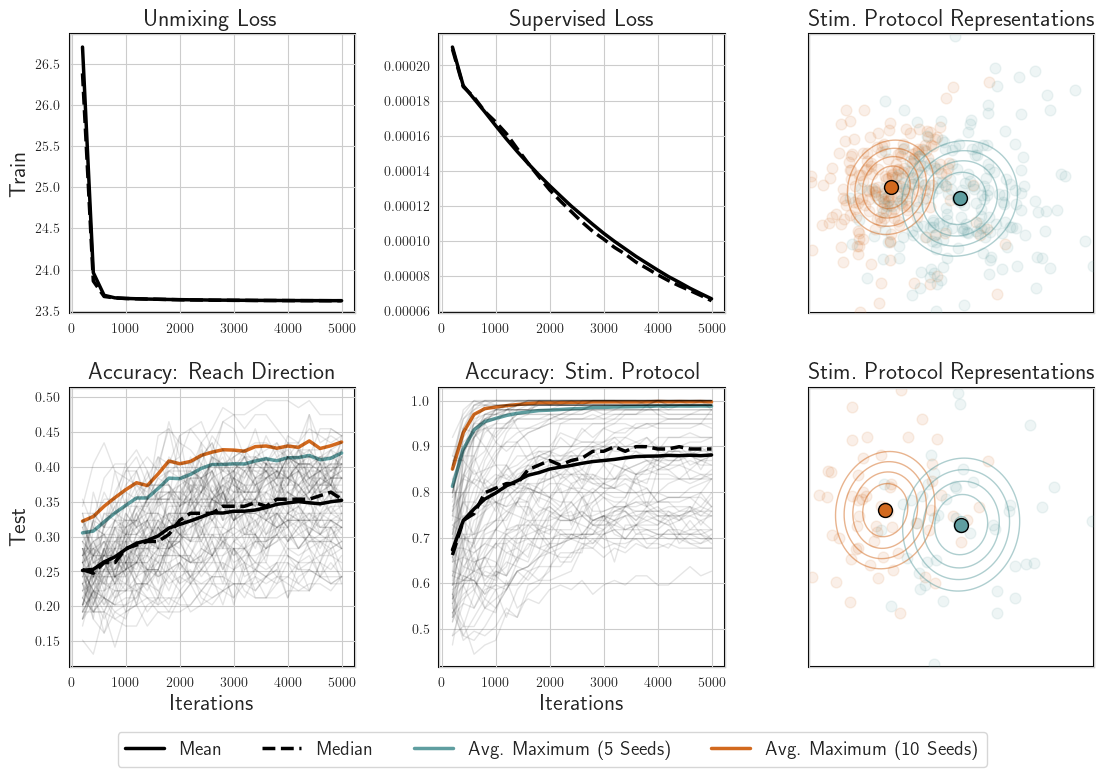

In [10]:
sns.set_style("whitegrid")

dataset = "reach-2021-09-22"
lam = 1e-4
lr_model = 1e-4

df1 = df[
    (df["lam"] == lam) & (df["dataset"] == dataset) & (df["lr_model"]==lr_model)
]

scale = 3.8
fig, axes = plt.subplots(2, 3, figsize=(scale * 3, scale * 2))
color = "darkcyan"

limit = 1
create_method_ax(axes[0, 0], df1, "train_unsup", limit=limit, color=color)
create_method_ax(axes[0, 1], df1, "train_sup", limit=limit, color=color)
create_method_ax(axes[1, 0], df1, "test_accuracy_task_0", limit=limit, color=color)
create_method_ax(axes[1, 1], df1, "test_accuracy_task_1", limit=limit, color=color)

out = np.load("output/feat1_tr_whit.npy")
target_idx = 1
labs = y_train[:, target_idx]
create_scatter_ax(axes[0, 2], out, labs)

out = np.load("output/feat1_te_whit.npy")
target_idx = 1
labs = y_test[:, target_idx]
create_scatter_ax(axes[1, 2], out, labs)

axes[0, 0].set_title("Unmixing Loss")
axes[0, 1].set_title("Supervised Loss")
axes[1, 0].set_title("Accuracy: Reach Direction")
axes[1, 1].set_title("Accuracy: Stim.~Protocol")
axes[0, 2].set_title("Stim.~Protocol Representations")
axes[1, 2].set_title("Stim.~Protocol Representations")

axes[1, 0].set_xlabel("Iterations")
axes[1, 1].set_xlabel("Iterations")

axes[0, 0].set_ylabel("Train")
axes[1, 0].set_ylabel("Test")

handles, labels = join_handles_and_labels(axes)
fig.legend(handles=handles, labels=labels, loc='center', bbox_to_anchor=(0.5, -0.01), ncol=4)
fig.tight_layout(pad=2)
plt.savefig(f"../figures/icassp_{dataset}.pdf", bbox_inches="tight")
plt.show()